In [2]:
import astsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pandas as pd

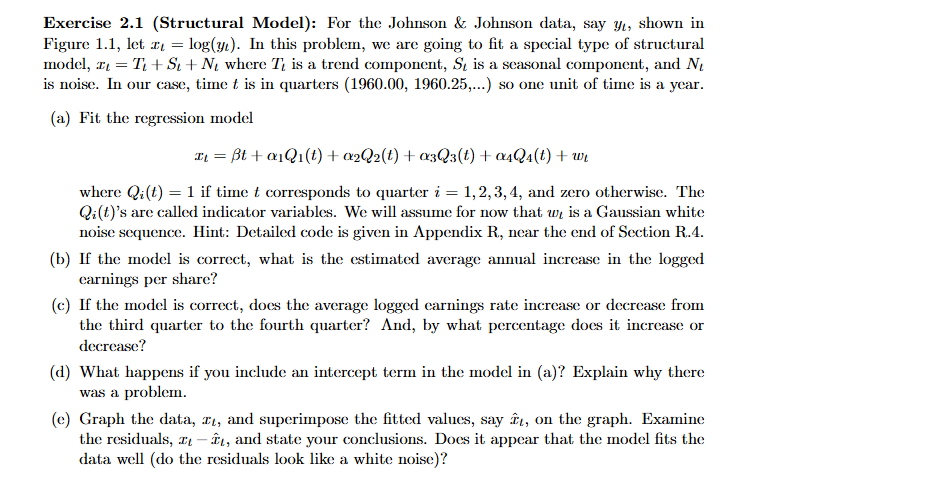

In [3]:
df = astsa.load_jj()
df['Value'] = np.log(df['Value'])
df['Year'] = df['Time'].str.slice(0,4).astype(int)
df['Quarter'] = df['Time'].str.slice(6,7).astype(int)
df['Time Value'] = df['Year'] + (df['Quarter']-1)/4
df.head()

,Time,Value,Year,Quarter,Time Value
0,1960-Q1,-0.342490,1960,1,1960.00
1,1960-Q2,-0.462035,1960,2,1960.25
2,1960-Q3,-0.162519,1960,3,1960.50
3,1960-Q4,-0.820981,1960,4,1960.75
4,1961-Q1,-0.494296,1961,1,1961.00


In [4]:
dfOLS = pd.get_dummies(df, columns=['Quarter'], dtype='float')
X = dfOLS[['Time Value', 'Quarter_1', 'Quarter_2', 'Quarter_3', 'Quarter_4']]
Y = dfOLS['Value']
olsModel = sm.OLS(Y, X).fit()
olsModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Value   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1379.
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           3.33e-72
Time:                        17:55:23   Log-Likelihood:                 57.808
No. Observations:                  84   AIC:                            -105.6
Df Residuals:                      79   BIC:                            -93.46
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Time Value     0.1672      0.002     73.999      0.000       0.163       0.172
Quarter_1   -328.2764      4.451    -73.761      0.000    -337.135    -319.418
Quarter_2   -328.2482      4.451    -73.745      0.000    -337.108    -319.389
Quarter_3   -328.1781      4.452    -73.720      0.000    -337.039    -319.317
Quarter_4   -328.4469      4.452    -73.771      0.000    -337.309    -319.585
==============================================================================
Omnibus:                        0.996   Durbin-Watson:                   1.274
Prob(Omnibus):                  0.608   Jarque-Bera (JB):                1.065
Skew:                           0.178   Prob(JB):                        0.587
Kurtosis:                       2.578   Cond. No.                     1.28e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

(B) If the model is correct, the annual increase in logged earnings per share is around 16.72%

In [5]:
beta3 = olsModel.params['Quarter_3']
beta4 = olsModel.params['Quarter_4']
beta = olsModel.params['Time Value']
netChange = (beta4 - beta3) + (beta/4)
netChange

np.float64(-0.2269646426854424)

(C) If the model is correct, the average difference in logged earnings per share from quarter 3 to quarter 4 is ~ -22.69%

(D) The model suffers from multi-collinearity as all the predictors are linearly dependent. The intercept column is simply the sum of all the quarter columns for a given row. This violates an OLS assumption and makes our matrix non-invertible.

(E)

<Axes: xlabel='Time Value', ylabel='Value'>

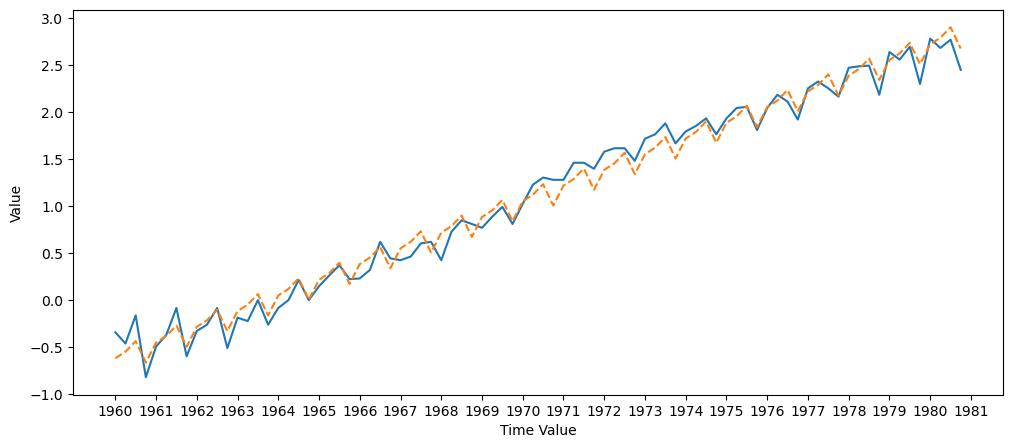

In [6]:
dfOLS['Fitted'] = olsModel.fittedvalues
dfOLS['Residuals'] = olsModel.resid
plt.figure(figsize=(12,5))
plt.xticks(np.arange(1960, 1985, 1))
sns.lineplot(x=df['Time Value'], y=df['Value'])
sns.lineplot(x=df['Time Value'], y=dfOLS['Fitted'], linestyle='--')

<Axes: xlabel='Time Value', ylabel='Residuals'>

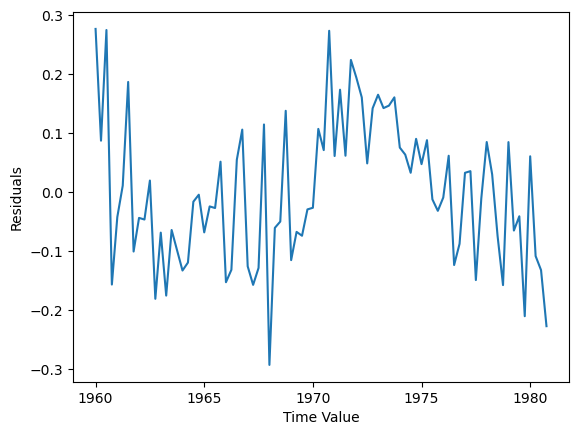

In [7]:
#Plotting residuals
sns.lineplot(x=df['Time Value'], y=dfOLS['Residuals'])

By looking at the superimposed graph and the graph of the residuals, it appears that the residuals are not gaussian white noise and instead appear to follow a cyclical or wavelike pattern.